In [23]:
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import skfuzzy as fuzz
from skfuzzy import control as ctrl


LOAD DATA

In [31]:
df = pd.read_csv("../../data/processed/cleaned_data.csv")
df.fillna(0, inplace=True)

df_original = df.copy()

In [32]:
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values('date_time').reset_index(drop=True)

df = df.fillna(method='ffill')
df['holiday'] = df['holiday'].fillna('None')


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11140\4015620399.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [28]:
df['date_time'] = pd.to_datetime(df['date_time'])

df = df.sort_values('date_time').reset_index(drop=True)

In [33]:
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [34]:
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

df['traffic_lag_1'] = df['traffic_volume'].shift(1)
df['traffic_lag_24'] = df['traffic_volume'].shift(24)

df = pd.get_dummies(df, columns=['holiday'], drop_first=True)


In [36]:
df = df.drop(columns=['date_time','weather_description'])

df = df.dropna()

In [35]:
df.shape

(48187, 39)

In [37]:
split = int(0.8 * len(df))

train_df = df[:split]
test_df = df[split:]

X_train = train_df.drop(columns=['traffic_volume'])
y_train = train_df['traffic_volume']

X_test = test_df.drop(columns=['traffic_volume'])
y_test = test_df['traffic_volume']

LOAD SCALER and ALIGN FEATURES


In [40]:
import joblib
import pandas as pd

scaler = joblib.load("X_scaler.pkl")

# Convert to DataFrame (IMPORTANT)
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# Get expected columns from scaler
expected_cols = list(scaler.feature_names_in_)

# -------------------------
# FIX TRAIN DATA
# -------------------------
for col in expected_cols:
    if col not in X_train.columns:
        X_train[col] = 0

X_train = X_train[expected_cols]

# -------------------------
# FIX TEST DATA
# -------------------------
for col in expected_cols:
    if col not in X_test.columns:
        X_test[col] = 0

X_test = X_test[expected_cols]

# -------------------------
# SCALE
# -------------------------
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

TRAIN-TEST SPLIT

CREATE SEQUENCES

In [41]:
def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y.iloc[i+time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 24

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIME_STEPS)

print("X_test_seq:", X_test_seq.shape)


X_test_seq: (9609, 24, 36)


LOAD MODEL

In [42]:
model = tf.keras.models.load_model("traffic_model.h5", compile=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)


PREDICT (LSTM)

In [43]:
y_pred = model.predict(X_test_seq)


301/301 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


FUZZY SYSTEM (SOFT COMPUTING)

In [44]:
traffic_pred = ctrl.Antecedent(np.arange(0, 8000, 1), 'traffic_pred')
hour = ctrl.Antecedent(np.arange(0, 24, 1), 'hour')
clouds = ctrl.Antecedent(np.arange(0, 100, 1), 'clouds')

final_output = ctrl.Consequent(np.arange(0, 8000, 1), 'final_output')

Membership functions

In [45]:
traffic_pred['low'] = fuzz.trimf(traffic_pred.universe, [0, 0, 3000])
traffic_pred['medium'] = fuzz.trimf(traffic_pred.universe, [2000, 4000, 6000])
traffic_pred['high'] = fuzz.trimf(traffic_pred.universe, [5000, 8000, 8000])

hour['off_peak'] = fuzz.trimf(hour.universe, [0, 0, 10])
hour['peak'] = fuzz.trimf(hour.universe, [8, 14, 20])
hour['night'] = fuzz.trimf(hour.universe, [18, 23, 23])

clouds['low'] = fuzz.trimf(clouds.universe, [0, 0, 50])
clouds['high'] = fuzz.trimf(clouds.universe, [50, 100, 100])

final_output['low'] = fuzz.trimf(final_output.universe, [0, 0, 3000])
final_output['medium'] = fuzz.trimf(final_output.universe, [2000, 4000, 6000])
final_output['high'] = fuzz.trimf(final_output.universe, [5000, 8000, 8000])


Fuzzy Rules

In [11]:
rule_default = ctrl.Rule(traffic_pred['medium'], final_output['medium'])
rule1 = ctrl.Rule(traffic_pred['high'] & hour['peak'], final_output['high'])
rule2 = ctrl.Rule(traffic_pred['medium'] & hour['peak'], final_output['high'])
rule3 = ctrl.Rule(traffic_pred['low'] & hour['off_peak'], final_output['low'])
rule4 = ctrl.Rule(clouds['high'] & traffic_pred['medium'], final_output['medium'])
rule5 = ctrl.Rule(traffic_pred['low'] & hour['night'], final_output['low'])

fuzzy_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule_default
])

 APPLY FUZZY

In [12]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [46]:
fuzzy_preds = []

for i in range(len(y_pred)):
    fuzzy_sim = ctrl.ControlSystemSimulation(fuzzy_ctrl)

    pred = y_pred[i][0]

    # correct index mapping
    idx = split + i + 24

    hour_val = df.iloc[idx]['hour']
    clouds_val = df.iloc[idx]['clouds_all']

    fuzzy_sim.input['traffic_pred'] = pred
    fuzzy_sim.input['hour'] = hour_val
    fuzzy_sim.input['clouds'] = clouds_val

    try:
        fuzzy_sim.compute()
        output = fuzzy_sim.output['final_output']
    except:
        output = pred  # fallback

    fuzzy_preds.append(output)

EVALUATION

In [47]:
mse_nn = mean_squared_error(y_test_seq, y_pred)
mse_fuzzy = mean_squared_error(y_test_seq, fuzzy_preds)

print("\n===== RESULTS =====")
print("LSTM MSE:", mse_nn)
print("Neuro-Fuzzy MSE:", mse_fuzzy)


===== RESULTS =====
LSTM MSE: 233486.671875
Neuro-Fuzzy MSE: 833359.1097717969


In [48]:
y_pred
fuzzy_preds
y_test_seq

array([5428, 5987, 6775, ..., 2159, 1450,  954], shape=(9609,))

GRAPH 


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten arrays
y_pred_flat = np.array(y_pred).flatten()
fuzzy_preds_flat = np.array(fuzzy_preds).flatten()
y_true = np.array(y_test_seq).flatten()

# Limit points for clear graph
n = 200
y_true_plot = y_true[:n]
y_pred_plot = y_pred_flat[:n]
fuzzy_plot = fuzzy_preds_flat[:n]

1. Actual vs LSTM

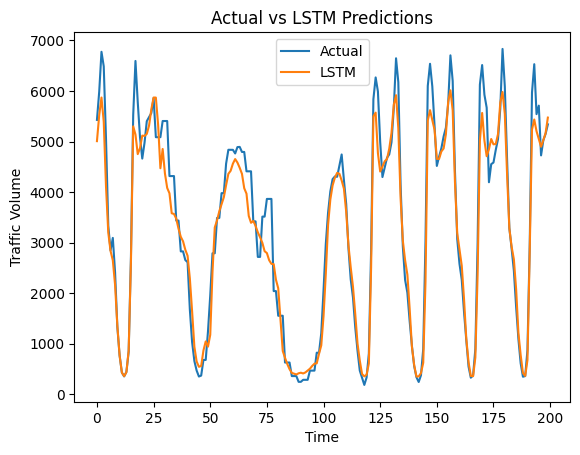

In [50]:
plt.figure()
plt.plot(y_true_plot, label="Actual")
plt.plot(y_pred_plot, label="LSTM")
plt.title("Actual vs LSTM Predictions")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.legend()
plt.show()

2. Actual vs Neuro-Fuzzy

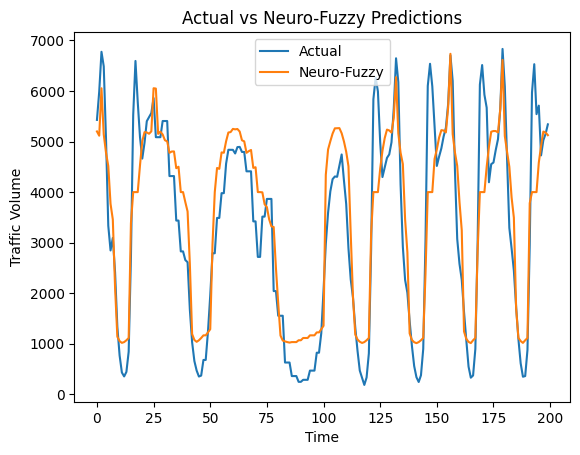

In [51]:
plt.figure()
plt.plot(y_true_plot, label="Actual")
plt.plot(fuzzy_plot, label="Neuro-Fuzzy")
plt.title("Actual vs Neuro-Fuzzy Predictions")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.legend()
plt.show()

3. LSTM vs Neuro-Fuzzy

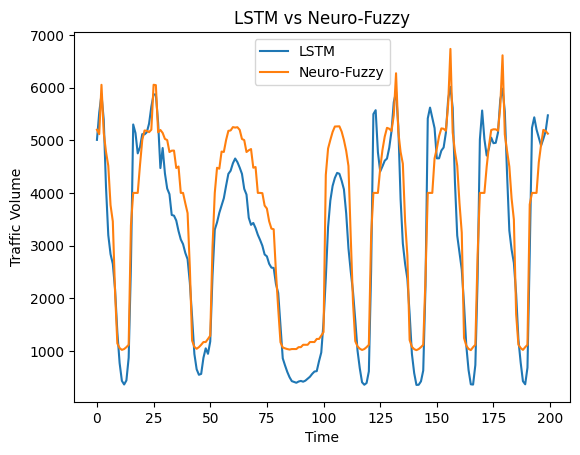

In [52]:
plt.figure()
plt.plot(y_pred_plot, label="LSTM")
plt.plot(fuzzy_plot, label="Neuro-Fuzzy")
plt.title("LSTM vs Neuro-Fuzzy")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.legend()
plt.show()

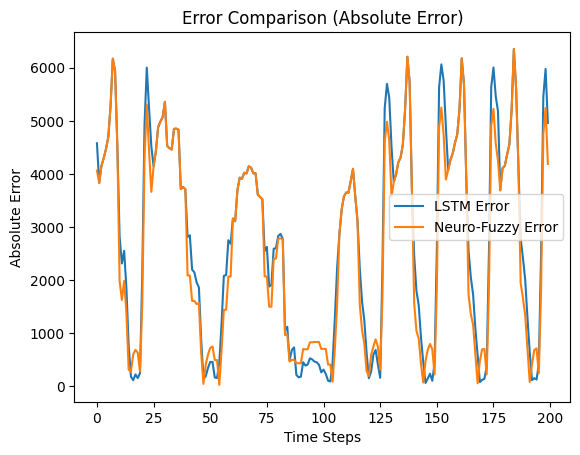

Average LSTM Error: 2769.8186040250976
Average Neuro-Fuzzy Error: 2565.4765116017006


In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy
y_true = np.array(y_test_seq).flatten()
y_pred_flat = np.array(y_pred).flatten()
fuzzy_preds_flat = np.array(fuzzy_preds).flatten()

# ERROR CALCULATION

error_nn = np.abs(y_true - y_pred_flat)
error_fuzzy = np.abs(y_true - fuzzy_preds_flat)

plt.figure()
plt.plot(error_nn[:200], label="LSTM Error")
plt.plot(error_fuzzy[:200], label="Neuro-Fuzzy Error")
plt.title("Error Comparison (Absolute Error)")
plt.xlabel("Time Steps")
plt.ylabel("Absolute Error")
plt.legend()
plt.show()


print("Average LSTM Error:", np.mean(error_nn))
print("Average Neuro-Fuzzy Error:", np.mean(error_fuzzy))

SAVE OUTPUTS

In [39]:
np.save("nn_predictions.npy", y_pred)
np.save("fuzzy_predictions.npy", fuzzy_preds)

In [53]:
model.save("traffic_model_fuzzy.h5")
joblib.dump(scaler, "X_scaler.pkl")

['X_scaler.pkl']